### **Projeto Extensionista - Tópicos de Big Data em Python**

- **Faculdade Estácio de Sá RJ (UNESA)**
- **Aluno:** José Roberto Duarte Hegendorne  
- **Matrícula:** 202502214154  
- **Curso:** Presencial  
- **Professora:** Simone Gama  
- **Período:** 1º semestre 2026

**Tema:** Análise dos Dados do Sistema de Bilhetagem Eletrônica (RioCard)

**Fonte dos dados:** https://dadosabertos.rj.gov.br/dataset/setram_sbe

In [1]:
import pandas as pd # Biblioteca para manipulação de dados
import numpy as np # Biblioteca para operações numéricas
import matplotlib.pyplot as plt # Biblioteca para visualização de dados
import seaborn as sns # Biblioteca para visualização de dados estatísticos
import re # Biblioteca para expressões regulares (limpeza de hash)
import os # Biblioteca para manipulação de arquivos
import zipfile # Biblioteca para manipulação de arquivos zip
from sklearn.linear_model import LinearRegression #
from sklearn.metrics import r2_score, mean_squared_error



In [2]:
# Configurações de visualização
sns.set(style="whitegrid")
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f8f6',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

## **1. Carregamento dos Dados**

In [3]:
# 0. Passo: Baixar os arquivos da pasta 'dados' do GitHub (raw URLs) para o Colab
Diretorio = os.path.join(".", "dados")
os.makedirs(Diretorio, exist_ok=True)

BASE_URL_RAW = "https://raw.githubusercontent.com/Heggendorn/facul/7d1dc57b88b1e3a444a84c7d7058252811e6fff8/dados/"


arquivos_zip = [
    "transacao_be_publico_2026_03_16_csv.zip",
    "transacao_be_publico_2026_03_17_csv.zip",
    "transacao_be_publico_2026_03_18_csv.zip",
]

for nome_arquivo in arquivos_zip:
    caminho_local = os.path.join(Diretorio, nome_arquivo)
    if not os.path.exists(caminho_local):
        url = f"{BASE_URL_RAW}/{nome_arquivo}"
        print(f"Baixando: {nome_arquivo}")
        resposta = requests.get(url)
        if resposta.status_code == 200:
            with open(caminho_local, 'wb') as f:
                f.write(resposta.content)
            print(f"  -> Salvo em {caminho_local} ({len(resposta.content)/1e6:.1f} MB)")
        else:
            print(f"  -> Erro ao baixar {nome_arquivo}: status {resposta.status_code}")
    else:
        print(f"Já existe localmente: {nome_arquivo}")


# 1. Define o caminho relativo para a pasta "dados"
# (já definido acima, mantido aqui por clareza)
# Diretorio = os.path.join(".", "dados")


def extrair_data_do_nome(nome_arquivo):
    """
    Extrai a data esperada a partir do nome do arquivo.
    Espera padrão: transacao_be_publico_AAAA_MM_DD_csv.zip
    Retorna um objeto date ou None se não encontrar.
    """
    match = re.search(r'(\d{4})_(\d{2})_(\d{2})', nome_arquivo)
    if match:
        ano, mes, dia = match.groups()
        try:
            return pd.Timestamp(int(ano), int(mes), int(dia)).date()
        except ValueError:
            return None
    return None


def Carregar_Dados(quantidade_linhas=None, arquivo_zip=r""):
    try:
        # Abre o arquivo ZIP em modo de leitura
        with zipfile.ZipFile(arquivo_zip, 'r') as z:
            # Lista os arquivos de dentro do ZIP e filtra para achar o arquivo CSV
            arquivos_internos = z.namelist()
            csv_encontrado = [f for f in arquivos_internos if f.endswith('.csv')]

            if not csv_encontrado:
                print(f"Nenhum CSV encontrado dentro do zip: {os.path.basename(arquivo_zip)}")
                return None

            # Abre o primeiro CSV encontrado dentro do ZIP sem precisar extrair para o disco
            with z.open(csv_encontrado[0]) as f:
                dados_df = pd.read_csv(f, encoding='utf-8-sig', sep=';', nrows=quantidade_linhas)
                return dados_df
    except Exception as e:
        print(f"Erro ao carregar os dados do arquivo {os.path.basename(arquivo_zip)}: {e}")
        return None


def Descontaminar_Datas(df, nome_arquivo):
    """
    Valida e limpa o dataframe de um arquivo individual.

    Fluxo:
    1. Extrai a data esperada do nome do arquivo (AAAA_MM_DD).
    2. Converte 'Data da Transação' (formato dd/mm/aaaa) para datetime.
    3. Calcula a data máxima presente no CSV.
    4. Se data_nome != data_maxima_csv -> descarta o arquivo inteiro (retorna None).
    5. Caso contrário, remove apenas as linhas cuja data não seja a data esperada.
    """
    if 'Data da Transação' not in df.columns:
        print(f"  -> Aviso: coluna 'Data da Transação' não encontrada em {nome_arquivo}. Arquivo descartado.")
        return None

    # 1. Passo: Extrai a data esperada do nome do arquivo
    data_nome = extrair_data_do_nome(nome_arquivo)
    if data_nome is None:
        print(f"  -> Aviso: não foi possível extrair data do nome '{nome_arquivo}'. Arquivo descartado.")
        return None

    # 2. Passo: Converte a coluna 'Data da Transação' (formato dd/mm/aaaa) para datetime
    datas_convertidas = pd.to_datetime(df['Data da Transação'], dayfirst=True, errors='coerce')

    if datas_convertidas.isna().all():
        print(f"  -> Aviso: não foi possível converter nenhuma data em {nome_arquivo}. Arquivo descartado.")
        return None

    # 3. Passo: Calcula a data máxima presente no CSV
    data_maxima_csv = datas_convertidas.max().date()

    # 4. Passo: Compara data do nome com a data máxima do CSV
    if data_nome != data_maxima_csv:
        print(f"  -> Data do nome ({data_nome}) != Data máxima do CSV ({data_maxima_csv}). "
              f"Arquivo '{nome_arquivo}' DESCARTADO por inconsistência.")
        return None

    # 5. Passo: Remove as linhas cuja data não seja a data esperada (data_nome)
    linhas_antes = len(df)
    mascara_validas = datas_convertidas.dt.date == data_nome
    df_filtrado = df[mascara_validas].copy()
    linhas_depois = len(df_filtrado)
    linhas_removidas = linhas_antes - linhas_depois
    pct_removido = (linhas_removidas / linhas_antes * 100) if linhas_antes else 0

    print(f"  -> Data validada: {data_nome} | "
          f"Removidas {linhas_removidas:,} de {linhas_antes:,} linhas ({pct_removido:.2f}%)")

    return df_filtrado


# Lista para armazenar o DataFrame de cada arquivo zipado
lista_dfs = []

# Verifica se a pasta "dados" existe no local do script
if os.path.exists(Diretorio):
    # Percorre todos os arquivos dentro do diretório "dados"
    for nome_arquivo in os.listdir(Diretorio):
        # Filtra para ler apenas arquivos que terminam com .zip
        if nome_arquivo.endswith('.zip'):
            caminho_completo = os.path.join(Diretorio, nome_arquivo)

            print(f"Processando: {nome_arquivo}")

            # Carrega os dados do arquivo zip atual
            df_individual = Carregar_Dados(quantidade_linhas=None, arquivo_zip=caminho_completo)

            # Se o arquivo foi lido com sucesso, valida e descontamina
            if df_individual is not None:
                df_individual = Descontaminar_Datas(df_individual, nome_arquivo)
                if df_individual is not None and len(df_individual) > 0:
                    lista_dfs.append(df_individual)

    # 2. Criar o DataFrame final (Bu_total) juntando todos os arquivos da lista
    if lista_dfs:
        Bu_total = pd.concat(lista_dfs, ignore_index=True)

        print(f"\nTotal de linhas carregadas de todos os ZIPs (após descontaminação): {len(Bu_total):,}")
        print(Bu_total.info())
    else:
        print("Nenhum arquivo ZIP com dados válidos foi encontrado na pasta 'dados'.")
else:
    print(f"A pasta 'dados' não foi encontrada. Certifique-se de criar a pasta chamada 'dados' ao lado do seu script Python.")

Já existe localmente: transacao_be_publico_2026_03_16_csv.zip
Já existe localmente: transacao_be_publico_2026_03_17_csv.zip
Já existe localmente: transacao_be_publico_2026_03_18_csv.zip
Processando: transacao_be_publico_2026_03_16_csv.zip
  -> Data validada: 2026-03-16 | Removidas 172,905 de 1,246,953 linhas (13.87%)
Processando: transacao_be_publico_2026_03_17_csv.zip
  -> Data validada: 2026-03-17 | Removidas 517,997 de 1,617,788 linhas (32.02%)
Processando: transacao_be_publico_2026_03_18_csv.zip
  -> Data validada: 2026-03-18 | Removidas 568,971 de 1,656,706 linhas (34.34%)

Total de linhas carregadas de todos os ZIPs (após descontaminação): 3,261,574
<class 'pandas.DataFrame'>
RangeIndex: 3261574 entries, 0 to 3261573
Data columns (total 14 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   Data do Processamento   str    
 1   Data da Transação       str    
 2   Nº Cartão               str    
 3   Cartão Hash             str    
 4   Descriç

## **2. Seleção e Renomeação das Colunas**

In [4]:
# Selecionando colunas relevantes
colunas = [
    "Data da Transação", "Nº Cartão", "Cartão Hash", "Descrição da Aplicação",
    "Sindicato", "Operadora", "Linha", "Sentido", "Nº Validador", 
    "Nº Carro", "Vl Linha", "Vl Trans", "Vl Subsídio"
]

Bu = Bu_total[colunas].copy()

# Renomeando colunas (padrão snake_case)
Bu.rename(columns={
    "Data da Transação": "Data_da_Transacao",
    "Nº Cartão": "N_Cartao",
    "Cartão Hash": "Cartao_Hash",
    "Descrição da Aplicação": "Descricao_da_Aplicacao",
    "Nº Validador": "N_Validador",
    "Nº Carro": "N_Carro",
    "Vl Linha": "Vl_Linha",
    "Vl Trans": "Vl_Trans",
    "Vl Subsídio": "Vl_Subsidio"
}, inplace=True)

## **3. Tratamento dos Dados**

In [5]:
# Tratamento do campo Sentido
Bu["Sentido"] = Bu["Sentido"].fillna(0)
Bu["Sentido"] = Bu["Sentido"].round().astype(int)
Bu["Sentido"] = Bu["Sentido"].map({0: "Desconhecido", 1: "Ida", 2: "Volta"})

## **Tratamento de Valores Monetários**

In [6]:
# Vl_Subsidio
Bu["Vl_Subsidio"] = Bu["Vl_Subsidio"].fillna(0)
Bu['Vl_Subsidio'] = (
    Bu['Vl_Subsidio']
    .astype(str)
    .str.replace('R$', '', regex=False)
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .str.strip()
    .astype(float)
)

# Vl_Linha e Vl_Trans
Bu["Vl_Linha"] = Bu["Vl_Linha"].str.replace(",", ".").astype(float)
Bu["Vl_Trans"] = Bu["Vl_Trans"].str.replace(",", ".").astype(float)

## **Tratamento de Data e Hora**

In [7]:
# Conversão de data
Bu["Data_da_Transacao"] = pd.to_datetime(Bu["Data_da_Transacao"],dayfirst=True,errors='coerce') 
Bu['hora'] = Bu['Data_da_Transacao'].dt.hour
Bu['data'] = Bu['Data_da_Transacao'].dt.date

## **Limpeza de Hash e Outros**

In [8]:
def limpar_hash(texto):
    """Substitui caracteres especiais por underscore (_), mantendo letras e números"""
    if pd.isna(texto) or texto is None:   # Correção aqui!
        return ""
    
    # Converte para string
    texto = str(texto)
    
    # Substitui tudo que não for letra ou número por "_"
    texto_limpo = re.sub(r'[^a-zA-Z0-9]',lambda m: str(ord(m.group())),texto)
    
    # Remove underscores múltiplos (___ vira _)
    texto_limpo = re.sub(r'_+', '_', texto_limpo)
    
    # Remove _ do início e fim
    texto_limpo = texto_limpo.strip('_')
    
    return texto_limpo


Bu['Cartao_Hash'] = Bu['Cartao_Hash'].apply(limpar_hash)
Bu['eh_qrcode'] = Bu['N_Cartao'].astype(str) == 'xxxxxx'

## **Removendo registros inválidos**

In [9]:
print(f"Antes da limpeza: {len(Bu):,} registros")

# Remoções
Bu = Bu[Bu["Vl_Linha"] > 0].copy()                    # Remove Vl_Linha = 0
Bu = Bu[Bu['Descricao_da_Aplicacao'] != '820-BARCAS MORADOR'].copy()
Bu = Bu.dropna(subset=["Linha", "Operadora", "Vl_Linha"]).copy()

print(f"Depois da limpeza: {len(Bu):,} registros")

Antes da limpeza: 3,261,574 registros
Depois da limpeza: 3,261,450 registros


## **Remoção de duplicatas**

In [10]:
# Remoção de duplicatas
print(f"Duplicatas encontradas: {Bu.duplicated().sum()}")
Bu = Bu.drop_duplicates().reset_index(drop=True)
print(f"Após remoção de duplicatas: {len(Bu):,} registros")

Duplicatas encontradas: 3095
Após remoção de duplicatas: 3,258,355 registros


## **Classificação de Perfil (Melhorada)**

In [11]:
# Define as condições lógicas
condicoes = [
    Bu["Vl_Trans"] == 0,
    (Bu["Vl_Subsidio"] > 0)
    & (abs(Bu["Vl_Trans"] + Bu["Vl_Subsidio"] - Bu["Vl_Linha"]) < 0.1),
    (Bu["Vl_Subsidio"] > 0)
    & (abs(Bu["Vl_Trans"] + Bu["Vl_Subsidio"] - Bu["Vl_Linha"]) >= 0.1),
]

# Define os resultados para cada condição
resultados = ["Gratuidade", "Subsidiado", "Integracao"]

# O padrão (else) será 'Pagamento_Integral'
Bu["Perfil"] = np.select(condicoes, resultados, default="Pagamento_Integral")
Bu['Diferenca'] = Bu['Vl_Linha'] - Bu['Vl_Trans']

## **4. Verificação Final da Base Tratada**

In [12]:
print("=== INFORMAÇÕES FINAIS DA BASE ===")
print(Bu.info())
print("\n=== VALORES NULOS ===")
print(Bu.isnull().sum())
print("\n=== DUPLICATAS ===")
print(Bu.duplicated().sum())

Bu.head()

=== INFORMAÇÕES FINAIS DA BASE ===
<class 'pandas.DataFrame'>
RangeIndex: 3258355 entries, 0 to 3258354
Data columns (total 18 columns):
 #   Column                  Dtype         
---  ------                  -----         
 0   Data_da_Transacao       datetime64[us]
 1   N_Cartao                str           
 2   Cartao_Hash             str           
 3   Descricao_da_Aplicacao  str           
 4   Sindicato               str           
 5   Operadora               str           
 6   Linha                   str           
 7   Sentido                 str           
 8   N_Validador             int64         
 9   N_Carro                 int64         
 10  Vl_Linha                float64       
 11  Vl_Trans                float64       
 12  Vl_Subsidio             float64       
 13  hora                    int32         
 14  data                    object        
 15  eh_qrcode               bool          
 16  Perfil                  str           
 17  Diferenca             

,Data_da_Transacao,N_Cartao,Cartao_Hash,Descricao_da_Aplicacao,Sindicato,Operadora,Linha,Sentido,N_Validador,N_Carro,Vl_Linha,Vl_Trans,Vl_Subsidio,hora,data,eh_qrcode,Perfil,Diferenca
0,2026-03-16 16:30:30,xxxxxx,NI6033H37G36DCY636046619596KMG41X6XVZ5M4062449...,80-QR CODE UNITÁRIO,METRÔ RIO,Concessao Metroviaria do Rio de Janeiro S. A.,L1 SPN - Estação Saens Peña - Metrô,Desconhecido,76835,1106,7.90,7.90,0.00,16,2026-03-16,True,Pagamento_Integral,0.00
1,2026-03-16 21:10:09,xxxxxx,NI6033H37G36DCY636046619596KMG41X6XVZ5M4062449...,80-QR CODE UNITÁRIO,METRÔ RIO,Concessao Metroviaria do Rio de Janeiro S. A.,L1 SPN - Estação Saens Peña - Metrô,Desconhecido,77164,1210,7.90,7.90,0.00,21,2026-03-16,True,Pagamento_Integral,0.00
2,2026-03-16 05:57:52,xxxxxx,NI6033H37G36DCY636046619596KMG41X6XVZ5M4062449...,80-QR CODE UNITÁRIO,METRÔ RIO,Concessao Metroviaria do Rio de Janeiro S. A.,L2 PVN - Estação Pavuna - Metrô,Desconhecido,77688,32208,7.90,7.90,0.00,5,2026-03-16,True,Pagamento_Integral,0.00
3,2026-03-16 09:03:24,xxxxxx,NI6033H37G36DCY636046619596KMG41X6XVZ5M4062449...,80-QR CODE UNITÁRIO,METRÔ RIO,Concessao Metroviaria do Rio de Janeiro S. A.,L2 PVN - Estação Pavuna - Metrô,Desconhecido,76919,32103,7.90,7.90,0.00,9,2026-03-16,True,Pagamento_Integral,0.00
4,2026-03-16 07:23:02,xxxxxx,NI6033H37G36DCY636046619596KMG41X6XVZ5M4062449...,80-QR CODE UNITÁRIO,METRÔ RIO,Concessao Metroviaria do Rio de Janeiro S. A.,L4 SCO - Estação São Conrado,Desconhecido,77239,64205,7.90,7.90,0.00,7,2026-03-16,True,Pagamento_Integral,0.00


---



## **5. ANÁLISE DESCRITIVA**


### 5.1 Estatísticas descritivas gerais e totais


In [13]:
# 5.1 - Estatísticas descritivas gerais e totais

# VARIAVEIS QUANTITATIVAS
print("=== ESTATÍSTICAS DESCRITIVAS GERAIS ===")
print(Bu[['Vl_Linha', 'Vl_Trans', 'Vl_Subsidio']].describe().round(2))
print("\n=== TOTAL GERAL ===")
print(f"Total de viagens: {len(Bu):,}")
print(f"Valor total pago pelos usuários: R$ {Bu['Vl_Trans'].sum():,.2f}")
print(f"Valor total subsidiado pelo governo: R$ {Bu['Vl_Subsidio'].sum():,.2f}")
print(f"Valor total das tarifas cheias: R$ {Bu['Vl_Linha'].sum():,.2f}")

# === NOVO: Evolução diária (base agora cobre múltiplos dias) ===
resumo_diario = Bu.groupby('data').agg(
    Total_Viagens=('Data_da_Transacao', 'count'),
    Total_Pago=('Vl_Trans', 'sum'),
    Total_Subsidio=('Vl_Subsidio', 'sum'),
    Total_Tarifa_Cheia=('Vl_Linha', 'sum')
).reset_index()

print("\n=== RESUMO POR DIA ===")
print(resumo_diario.round(2))

dia_maior_volume = resumo_diario.loc[resumo_diario['Total_Viagens'].idxmax()]
dia_menor_volume = resumo_diario.loc[resumo_diario['Total_Viagens'].idxmin()]
print(f"\nDia com maior volume de viagens: {dia_maior_volume['data']} ({dia_maior_volume['Total_Viagens']:,.0f} viagens)")
print(f"Dia com menor volume de viagens: {dia_menor_volume['data']} ({dia_menor_volume['Total_Viagens']:,.0f} viagens)")

=== ESTATÍSTICAS DESCRITIVAS GERAIS ===
        Vl_Linha   Vl_Trans  Vl_Subsidio
count 3258355.00 3258355.00   3258355.00
mean        9.98       7.38         2.60
std         4.73       4.24         3.95
min         2.50       0.00         0.00
25%         6.70       5.00         0.00
50%         7.60       6.70         0.00
75%        12.65       9.25         4.00
max        74.40      74.40        25.15

=== TOTAL GERAL ===
Total de viagens: 3,258,355
Valor total pago pelos usuários: R$ 24,044,001.56
Valor total subsidiado pelo governo: R$ 8,464,830.85
Valor total das tarifas cheias: R$ 32,528,182.91

=== RESUMO POR DIA ===
         data  Total_Viagens  Total_Pago  Total_Subsidio  Total_Tarifa_Cheia
0  2026-03-16        1072943  7789482.19      2713646.95         10511680.94
1  2026-03-17        1098667  8171913.81      2891921.25         11069734.16
2  2026-03-18        1086745  8082605.56      2859262.65         10946767.81

Dia com maior volume de viagens: 2026-03-17 (1,098,667 vi

### 5.2 Distribuição por Perfil de Passageiro


In [14]:
#   VARIAVEIS CATEGÓRICAS 
perfil = Bu['Perfil'].value_counts() # Quantidade de cada perfil
perfil_pct = Bu['Perfil'].value_counts(normalize=True) * 100 # Porcentagem de cada perfil em relação ao total
print("=== DISTRIBUIÇÃO POR PERFIL ===")
print(pd.DataFrame({
    'Quantidade': perfil,
    'Porcentagem (%)': perfil_pct.round(2)
}))

# === NOVO: Distribuição por perfil, dia a dia ===
perfil_por_dia = Bu.groupby(['data', 'Perfil']).size().unstack(fill_value=0)
perfil_por_dia_pct = perfil_por_dia.div(perfil_por_dia.sum(axis=1), axis=0) * 100

print("\n=== DISTRIBUIÇÃO POR PERFIL E DIA (Quantidade) ===")
print(perfil_por_dia)
print("\n=== DISTRIBUIÇÃO POR PERFIL E DIA (% dentro de cada dia) ===")
print(perfil_por_dia_pct.round(2))

=== DISTRIBUIÇÃO POR PERFIL ===
                    Quantidade  Porcentagem (%)
Perfil                                         
Pagamento_Integral     1804065            55.37
Subsidiado             1338921            41.09
Gratuidade              115369             3.54

=== DISTRIBUIÇÃO POR PERFIL E DIA (Quantidade) ===
Perfil      Gratuidade  Pagamento_Integral  Subsidiado
data                                                  
2026-03-16       37939              595245      439759
2026-03-17       38750              606308      453609
2026-03-18       38680              602512      445553

=== DISTRIBUIÇÃO POR PERFIL E DIA (% dentro de cada dia) ===
Perfil      Gratuidade  Pagamento_Integral  Subsidiado
data                                                  
2026-03-16        3.54               55.48       40.99
2026-03-17        3.53               55.19       41.29
2026-03-18        3.56               55.44       41.00


### 5.3 Painel Visual - Análise Descritiva (Bilhetagem Eletrônica RJ)
Composição por perfil, distribuição do valor pago, volume por hora e boxplot por perfil.


C:\Users\joseroberto\AppData\Local\Temp\ipykernel_26604\98522717.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=Bu, x='Perfil', y='Vl_Trans', ax=axes[1,1], palette='Set2')


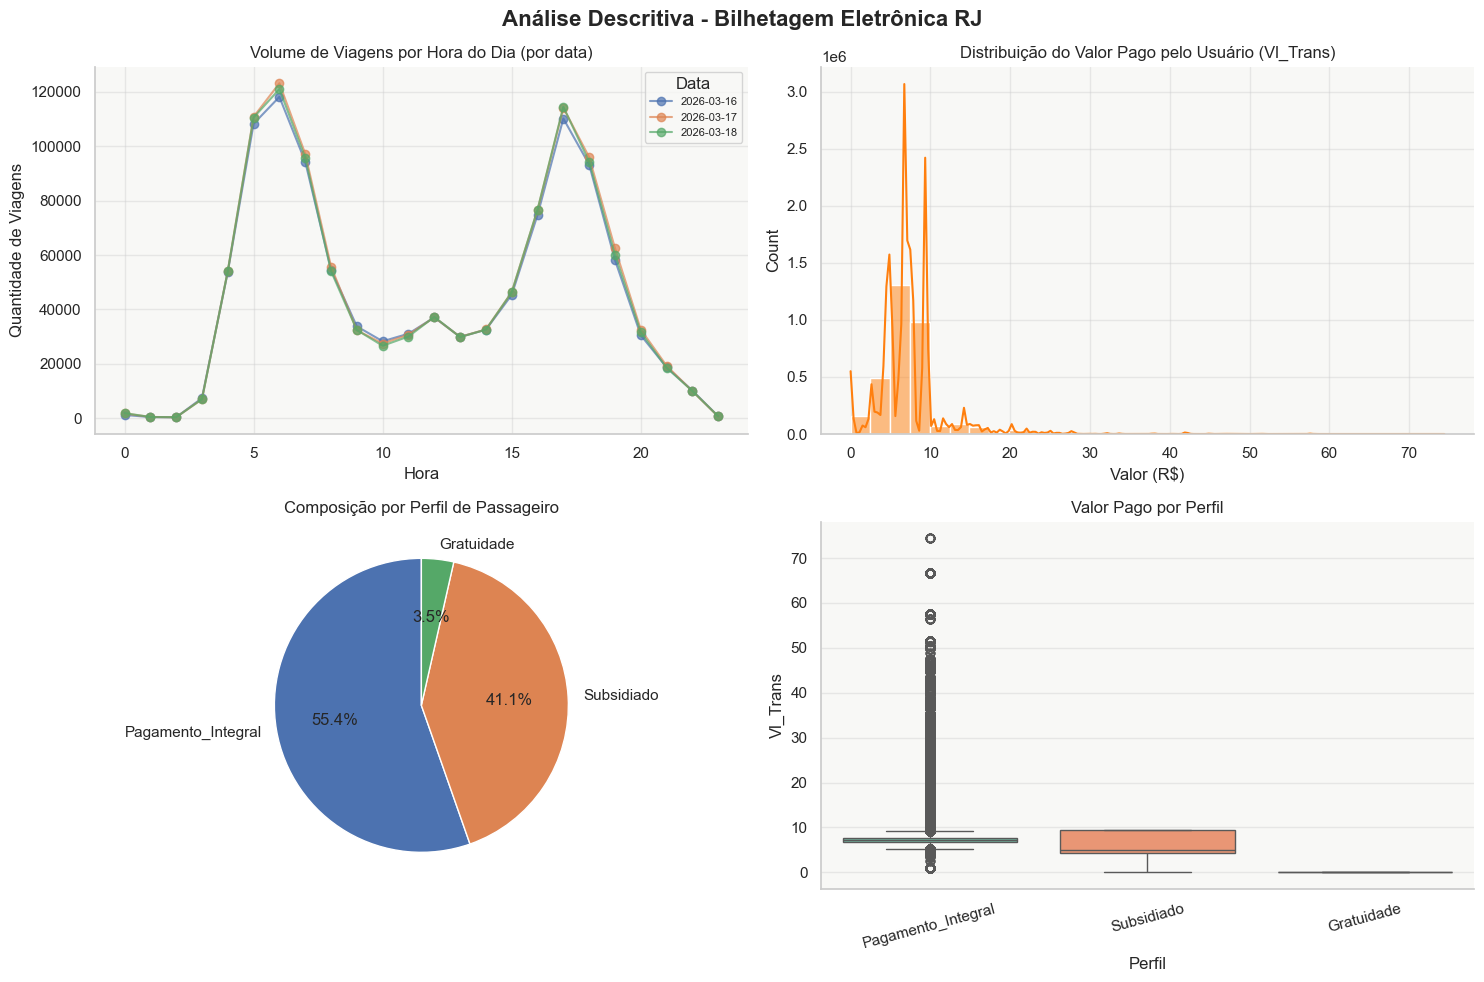

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Análise Descritiva - Bilhetagem Eletrônica RJ', fontsize=16, fontweight='bold')

# 1. Volume por hora — agora como média por dia, com uma linha por dia (em vez de soma agregada)
por_hora_dia = Bu.groupby(['data', 'hora']).size().unstack(level=0, fill_value=0)
for dia in por_hora_dia.columns:
    axes[0,0].plot(por_hora_dia.index, por_hora_dia[dia], marker='o', alpha=0.7, label=str(dia))
axes[0,0].set_title('Volume de Viagens por Hora do Dia (por data)')
axes[0,0].set_xlabel('Hora')
axes[0,0].set_ylabel('Quantidade de Viagens')
axes[0,0].legend(title='Data', fontsize=8)

# 2. Distribuição Vl_Trans (mantido agregado - faz sentido olhar a distribuição geral)
sns.histplot(Bu['Vl_Trans'], bins=30, kde=True, ax=axes[0,1], color='#ff7f0e')
axes[0,1].set_title('Distribuição do Valor Pago pelo Usuário (Vl_Trans)')
axes[0,1].set_xlabel('Valor (R$)')

# 3. Proporção por Perfil (mantido agregado)
axes[1,0].pie(perfil.values, labels=perfil.index, autopct='%1.1f%%', startangle=90)
axes[1,0].set_title('Composição por Perfil de Passageiro')

# 4. Boxplot por Perfil (mantido agregado)
sns.boxplot(data=Bu, x='Perfil', y='Vl_Trans', ax=axes[1,1], palette='Set2')
axes[1,1].set_title('Valor Pago por Perfil')
axes[1,1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('imgs/analise_descritiva4graficos.png', bbox_inches='tight', dpi=150)
plt.show()

### 5.4 Agrupamento Binário: Pagamento Integral x Com Subsídio
Criação da coluna `Grupo_Pagamento`, que reclassifica o `Perfil` em duas categorias: `Pagamento_Integral` (sem nenhum benefício) e `Com_Subsidio` (Subsidiado, Integração ou Gratuidade).


In [16]:
# === Criação do agrupamento binário: Pagamento Integral x Com Subsídio ===
Bu['Grupo_Pagamento'] = Bu['Perfil'].apply(
    lambda x: 'Pagamento_Integral' if x == 'Pagamento_Integral' else 'Com_Subsidio'
)# Cria uma nova coluna 'Grupo_Pagamento' onde 'Pagamento_Integral' permanece igual e os outros perfis são agrupados como 'Com_Subsidio'

print("=== DISTRIBUIÇÃO DO AGRUPAMENTO BINÁRIO ===")
print(Bu['Grupo_Pagamento'].value_counts())
print(Bu['Grupo_Pagamento'].value_counts(normalize=True).mul(100).round(2))

=== DISTRIBUIÇÃO DO AGRUPAMENTO BINÁRIO ===
Grupo_Pagamento
Pagamento_Integral    1804065
Com_Subsidio          1454290
Name: count, dtype: int64
Grupo_Pagamento
Pagamento_Integral   55.37
Com_Subsidio         44.63
Name: proportion, dtype: float64


=== ESTATÍSTICAS DESCRITIVAS POR GRUPO DE PAGAMENTO ===
                     Vl_Linha                                         \
                        count  mean  std  min  25%   50%   75%   max   
Grupo_Pagamento                                                        
Com_Subsidio       1454290.00 11.50 4.47 4.40 7.60 10.40 15.10 25.15   
Pagamento_Integral 1804065.00  8.76 4.58 2.50 6.70  7.10  7.70 74.40   

                     Vl_Trans                                     Vl_Subsidio  \
                        count mean  std  min  25%  50%  75%   max       count   
Grupo_Pagamento                                                                 
Com_Subsidio       1454290.00 5.67 2.99 0.00 4.40 5.00 9.40  9.40  1454290.00   
Pagamento_Integral 1804065.00 8.76 4.59 1.00 6.70 7.10 7.70 74.40  1804065.00   

                                                        
                   mean  std  min  25%  50%  75%   max  
Grupo_Pagamento                                         
Com_Su

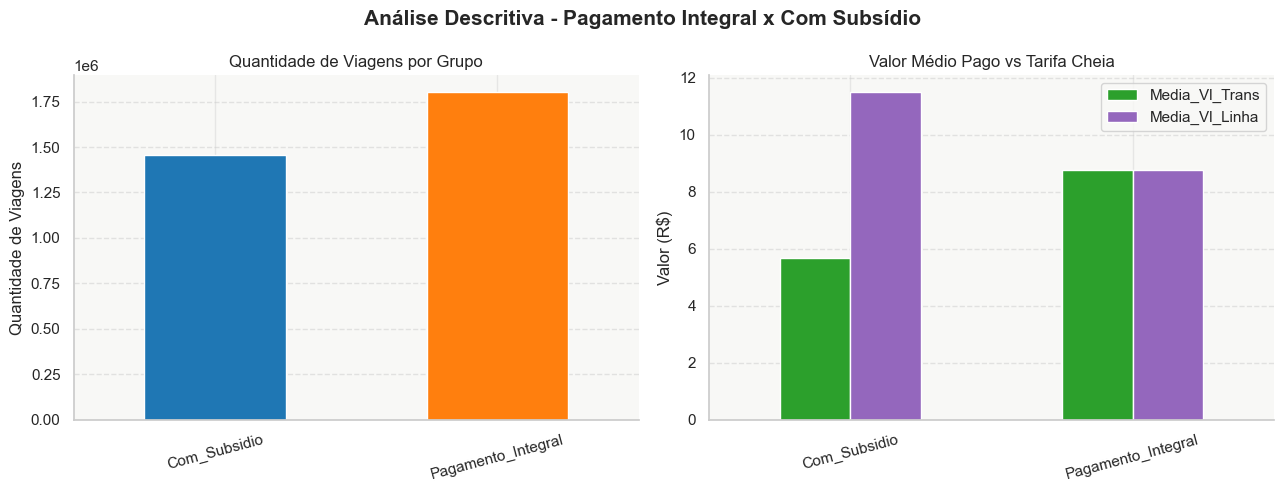

In [17]:
# === ANÁLISE DESCRITIVA: Pagamento Integral x Com Subsídio ===
print("=== ESTATÍSTICAS DESCRITIVAS POR GRUPO DE PAGAMENTO ===")
print(Bu.groupby('Grupo_Pagamento')[['Vl_Linha', 'Vl_Trans', 'Vl_Subsidio']].describe().round(2))

print("\n=== TOTAIS POR GRUPO ===")
resumo_grupo = Bu.groupby('Grupo_Pagamento').agg(
    Total_Viagens=('Data_da_Transacao', 'count'),
    Total_Pago=('Vl_Trans', 'sum'),
    Total_Subsidio=('Vl_Subsidio', 'sum'),
    Total_Tarifa_Cheia=('Vl_Linha', 'sum'),
    Media_Vl_Trans=('Vl_Trans', 'mean'),
    Media_Vl_Linha=('Vl_Linha', 'mean')
).round(2)
print(resumo_grupo)

# Gráfico de barras comparando médias
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Análise Descritiva - Pagamento Integral x Com Subsídio', fontsize=15, fontweight='bold')

resumo_grupo['Total_Viagens'].plot(kind='bar', ax=axes[0], color=['#1f77b4', '#ff7f0e'])
axes[0].set_title('Quantidade de Viagens por Grupo')
axes[0].set_ylabel('Quantidade de Viagens')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

resumo_grupo[['Media_Vl_Trans', 'Media_Vl_Linha']].plot(kind='bar', ax=axes[1], color=['#2ca02c', '#9467bd'])
axes[1].set_title('Valor Médio Pago vs Tarifa Cheia')
axes[1].set_ylabel('Valor (R$)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('imgs/descritiva_grupo_pagamento.png', bbox_inches='tight', dpi=150)
plt.show()
plt.close()

### 5.5 Estatísticas Descritivas Detalhadas por Grupo


In [18]:
# === ESTATÍSTICAS DESCRITIVAS - GRUPO PAGAMENTO INTEGRAL ===

dados_integral = Bu[Bu['Grupo_Pagamento'] == 'Pagamento_Integral']

media_vl_trans_integral = dados_integral['Vl_Trans'].mean()
mediana_vl_trans_integral = dados_integral['Vl_Trans'].median()
media_subsidio_integral = dados_integral['Vl_Subsidio'].mean()
desvio_subsidio_integral = dados_integral['Vl_Subsidio'].std()

print("=== PAGAMENTO INTEGRAL ===")
print(f"Tarifa média (Vl_Trans): R$ {media_vl_trans_integral:,.2f}")
print(f"Tarifa mediana (Vl_Trans): R$ {mediana_vl_trans_integral:,.2f}")
print(f"Média do subsídio (Vl_Subsidio): R$ {media_subsidio_integral:,.2f}")
print(f"Desvio padrão do subsídio (Vl_Subsidio): R$ {desvio_subsidio_integral:,.2f}")
print(dados_integral[['Vl_Linha', 'Vl_Trans', 'Vl_Subsidio']].describe().round(2))

=== PAGAMENTO INTEGRAL ===
Tarifa média (Vl_Trans): R$ 8.76
Tarifa mediana (Vl_Trans): R$ 7.10
Média do subsídio (Vl_Subsidio): R$ 0.00
Desvio padrão do subsídio (Vl_Subsidio): R$ 0.00
        Vl_Linha   Vl_Trans  Vl_Subsidio
count 1804065.00 1804065.00   1804065.00
mean        8.76       8.76         0.00
std         4.58       4.59         0.00
min         2.50       1.00         0.00
25%         6.70       6.70         0.00
50%         7.10       7.10         0.00
75%         7.70       7.70         0.00
max        74.40      74.40         0.00


In [19]:
# === ESTATÍSTICAS DESCRITIVAS - GRUPO COM SUBSÍDIO ===

dados_subsidio = Bu[Bu['Grupo_Pagamento'] == 'Com_Subsidio']

media_vl_linha_subsidio = dados_subsidio['Vl_Linha'].mean()
media_vl_trans_subsidio = dados_subsidio['Vl_Trans'].mean()
mediana_vl_trans_subsidio = dados_subsidio['Vl_Trans'].median()
media_subsidio = dados_subsidio['Vl_Subsidio'].mean()
desvio_subsidio = dados_subsidio['Vl_Subsidio'].std()

print("=== COM SUBSÍDIO ===")
print(f"Custo médio nominal da linha (Vl_Linha): R$ {media_vl_linha_subsidio:,.2f}")
print(f"Valor médio transacionado (Vl_Trans): R$ {media_vl_trans_subsidio:,.2f}")
print(f"Valor mediano transacionado (Vl_Trans): R$ {mediana_vl_trans_subsidio:,.2f}")
print(f"Aporte médio de subsídio (Vl_Subsidio): R$ {media_subsidio:,.2f}")
print(f"Desvio padrão do subsídio (Vl_Subsidio): R$ {desvio_subsidio:,.2f}")
print(dados_subsidio[['Vl_Linha', 'Vl_Trans', 'Vl_Subsidio']].describe().round(2))

=== COM SUBSÍDIO ===
Custo médio nominal da linha (Vl_Linha): R$ 11.50
Valor médio transacionado (Vl_Trans): R$ 5.67
Valor mediano transacionado (Vl_Trans): R$ 5.00
Aporte médio de subsídio (Vl_Subsidio): R$ 5.82
Desvio padrão do subsídio (Vl_Subsidio): R$ 4.02
        Vl_Linha   Vl_Trans  Vl_Subsidio
count 1454290.00 1454290.00   1454290.00
mean       11.50       5.67         5.82
std         4.47       2.99         4.02
min         4.40       0.00         0.00
25%         7.60       4.40         2.60
50%        10.40       5.00         4.85
75%        15.10       9.40         7.70
max        25.15       9.40        25.15


## **6. MODELAGEM ESTATÍSTICA: REGRESSÃO LINEAR**

Para aprofundar o entendimento sobre a dinâmica econômico-financeira do Sistema de Bilhetagem Eletrônica (RioCard), aplicou-se um modelo de **Regressão Linear Simples** via `scikit-learn`, isolando o comportamento do grupo **Subsidiado**, que recebe aporte governamental.

### 6.1 Definição do Problema e Premissas

O grupo de *Pagamento_Integral* possui uma relação estática e nula em relação ao subsídio (Vl_Subsidio = 0 para qualquer tarifa). Já o grupo *Subsidiado* apresenta uma variação que impacta diretamente os cofres públicos. A modelagem responde à pergunta: **"Para cada R$ 1,00 de aumento no valor nominal de uma linha de transporte (Vl_Linha), qual é o impacto médio gerado no valor do subsídio (Vl_Subsidio) custeado pelo governo?"**

- **Variável Independente (X):** `Vl_Linha` (Valor total da tarifa da linha)
- **Variável Dependente (Y):** `Vl_Subsidio` (Valor do subsídio pago pelo poder público)


In [20]:
# 1. Filtrar a base apenas para o grupo que recebe subsídio
# (Ignoramos as gratuidades e o pagamento integral para não zerar a conta)
dados_subsidio = Bu[Bu["Perfil"] == "Subsidiado"].copy()

# 2. Definir as variáveis da Regressão
# Queremos prever o Subsídio (Y) baseado no Valor Total da Linha (X)
X = dados_subsidio[["Vl_Linha"]]  # Variável independente (X deve ser 2D)
y = dados_subsidio["Vl_Subsidio"]  # Variável dependente/alvo

# 3. Importar as funções necessárias do scikit-learn
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 4. Criar e treinar o modelo
modelo_subsidio = LinearRegression()
modelo_subsidio.fit(X, y)

# 5. Gerar as previsões para a base
y_pred = modelo_subsidio.predict(X)

# 6. Exibir os resultados na tela
print("=" * 70)
print("REGRESSÃO LINEAR: IMPACTO DO VALOR DA LINHA NO SUBSÍDIO")
print("=" * 70)
print(f"Coeficiente Angular (Inclinação): {modelo_subsidio.coef_[0]:.4f}")
print(f"Intercepto (Eixo Y): {modelo_subsidio.intercept_:.4f}")
print(f"R² (Poder de explicação do modelo): {r2_score(y, y_pred):.4f}")
print(
    f"Erro Quadrático Médio (MSE): {mean_squared_error(y, y_pred):.4f}\n"
)

REGRESSÃO LINEAR: IMPACTO DO VALOR DA LINHA NO SUBSÍDIO
Coeficiente Angular (Inclinação): 0.6499
Intercepto (Eixo Y): -2.1285
R² (Poder de explicação do modelo): 0.6601
Erro Quadrático Médio (MSE): 4.2928



### 6.2 Visualização do Modelo de Regressão


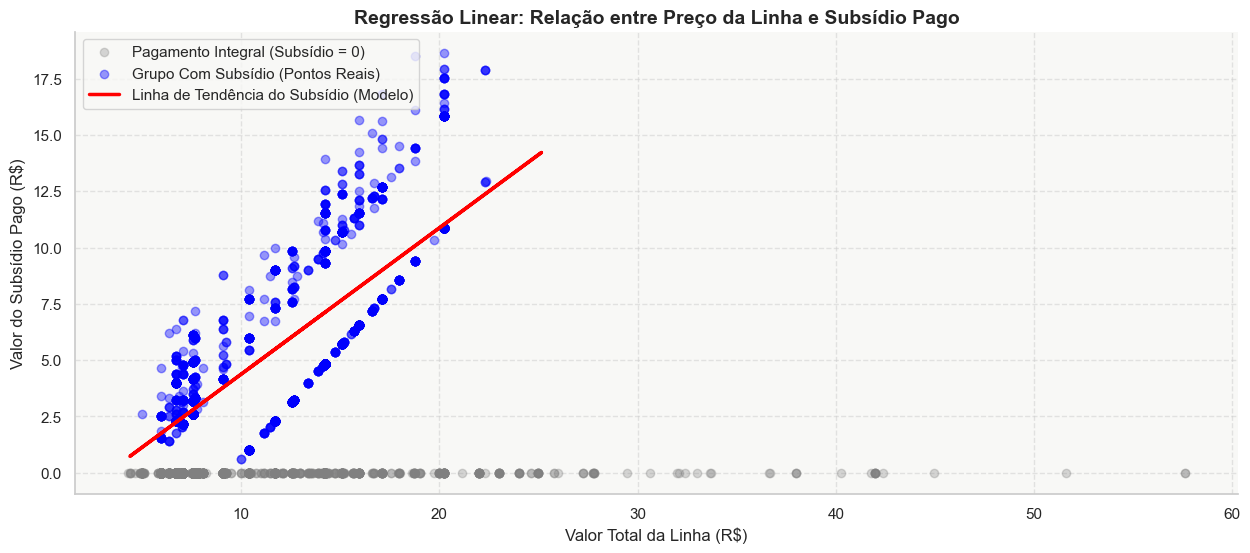

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 6))

# 1. Pegamos uma amostra aleatória de ambos os grupos para o gráfico não travar o computador
# (Plotar 3 milhões de pontos de uma vez pesaria demais na memória)
amostra_integral = Bu[Bu["Perfil"] == "Pagamento_Integral"].sample(
    n=3000, random_state=42
)
amostra_subsidio = Bu[Bu["Perfil"] == "Subsidiado"].sample(
    n=3000, random_state=42
)

# 2. Plotar os pontos reais das duas categorias
plt.scatter(
    amostra_integral["Vl_Linha"],
    amostra_integral["Vl_Subsidio"],
    alpha=0.3,
    color="gray",
    label="Pagamento Integral (Subsídio = 0)",
)
plt.scatter(
    amostra_subsidio["Vl_Linha"],
    amostra_subsidio["Vl_Subsidio"],
    alpha=0.4,
    color="blue",
    label="Grupo Com Subsídio (Pontos Reais)",
)

# 3. Plotar a linha vermelha da sua Regressão Linear por cima
plt.plot(
    X,
    y_pred,
    color="red",
    linewidth=2.5,
    label="Linha de Tendência do Subsídio (Modelo)",
)

# Configurações visuais do gráfico
plt.title(
    "Regressão Linear: Relação entre Preço da Linha e Subsídio Pago",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Valor Total da Linha (R$)")
plt.ylabel("Valor do Subsídio Pago (R$)")
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)

# Salva na sua pasta de imagens
plt.savefig("imgs/regressao_subsidio.png", bbox_inches="tight", dpi=150)
plt.show()

### 6.3 Análise e Interpretação dos Resultados

1. **Aderência do Modelo (R²):** o coeficiente de determinação de `0.6601` demonstra que o modelo possui alta capacidade de explicação para um modelo de linha única. Aproximadamente **66,01%** da variação do valor do subsídio é determinada diretamente pelo valor cheio da tarifa fixada para a linha (Vl_Linha). O restante (33,99%) decorre de regras de integração tarifária entre modais e baldeações temporais que não seguem uma proporcionalidade estritamente linear.

2. **Impacto Econômico (Coeficiente Angular):** o coeficiente de `0.6499` revela que, para o grupo de usuários beneficiados, cada acréscimo de **R$ 1,00** no valor total da tarifa (Vl_Linha) resulta em um acréscimo automático e médio de **R$ 0,65** no subsídio custeado pelo Estado. O intercepto negativo (`-2.1285`) delimita matematicamente o patamar mínimo tarifário a partir do qual as políticas de desconto e integração passam a operar com eficiência.

3. **Conclusão:** o subsídio não é um valor fixo por usuário, mas uma variável fortemente indexada ao valor da tarifa da linha. Esse modelo serve como ferramenta preditiva para estimar o impacto financeiro de futuros reajustes tarifários sobre o orçamento público.


6.4 # === REGRESSÃO LINEAR: Vl_Linha x Vl_Trans, separada por Grupo de Pagamento ===

C:\Users\joseroberto\AppData\Local\Temp\ipykernel_26604\2246939195.py:41: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\joseroberto\AppData\Local\Temp\ipykernel_26604\2246939195.py:42: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig('imgs/regressao_grupo_pagamento.png', bbox_inches='tight', dpi=150)
C:\Users\joseroberto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


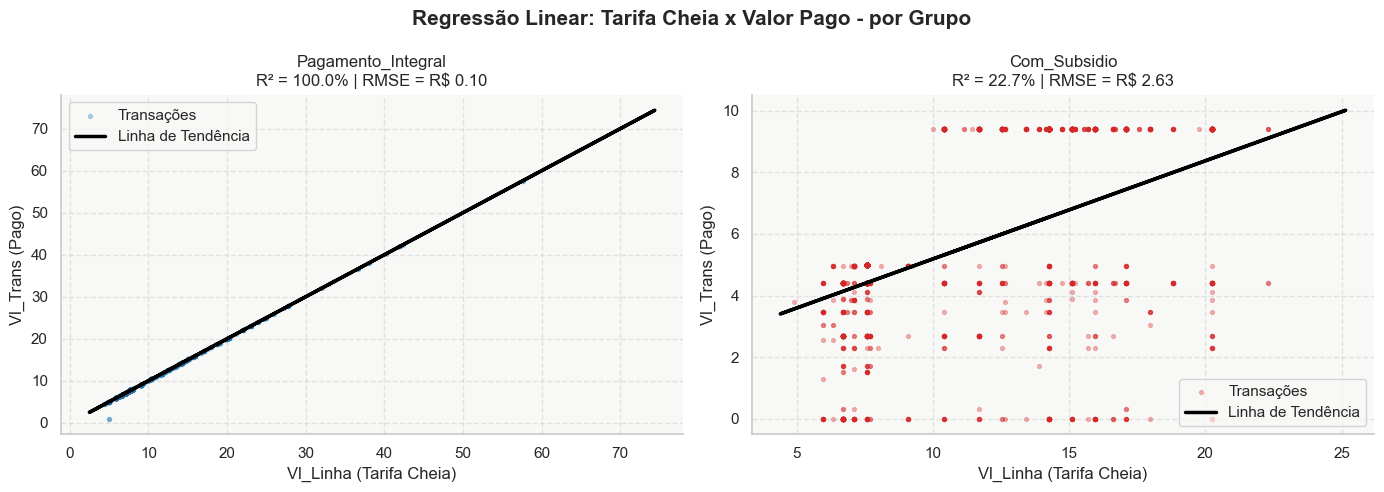

=== RESULTADOS DA REGRESSÃO POR GRUPO ===

Pagamento_Integral (n=1,804,065):
  Coeficiente angular: 1.0005
  Intercepto: -0.0067
  R²: 100.0%
  RMSE: R$ 0.10

Com_Subsidio (n=1,454,290):
  Coeficiente angular: 0.3190
  Intercepto: 1.9988
  R²: 22.7%
  RMSE: R$ 2.63


In [27]:
# === REGRESSÃO LINEAR: Vl_Linha x Vl_Trans, separada por Grupo de Pagamento ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Regressão Linear: Tarifa Cheia x Valor Pago - por Grupo', fontsize=15, fontweight='bold')

resultados_regressao = {}

for i, grupo in enumerate(['Pagamento_Integral', 'Com_Subsidio']):
    dados_grupo = Bu[Bu['Grupo_Pagamento'] == grupo].copy()

    X = dados_grupo[['Vl_Linha']]
    y = dados_grupo['Vl_Trans']

    modelo = LinearRegression()
    modelo.fit(X, y)
    y_pred = modelo.predict(X)

    r2 = r2_score(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))

    resultados_regressao[grupo] = {
        'coeficiente': modelo.coef_[0],
        'intercepto': modelo.intercept_,
        'r2': r2,
        'rmse': rmse,
        'n': len(dados_grupo)
    }

    cor = '#1f77b4' if grupo == 'Pagamento_Integral' else '#d62728'

    amostra_x = X.sample(min(2000, len(X)), random_state=42)
    amostra_y = y.sample(min(2000, len(y)), random_state=42)

    axes[i].scatter(amostra_x, amostra_y, alpha=0.3, s=8, color=cor, label='Transações')
    axes[i].plot(X, y_pred, color='black', linewidth=2.5, label='Linha de Tendência')
    axes[i].set_title(f'{grupo}\nR² = {r2*100:.1f}% | RMSE = R$ {rmse:.2f}')
    axes[i].set_xlabel('Vl_Linha (Tarifa Cheia)')
    axes[i].set_ylabel('Vl_Trans (Pago)')
    axes[i].legend()
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('imgs/regressao_grupo_pagamento.png', bbox_inches='tight', dpi=150)
plt.show()
plt.close()

print("=== RESULTADOS DA REGRESSÃO POR GRUPO ===")
for grupo, res in resultados_regressao.items():
    print(f"\n{grupo} (n={res['n']:,}):")
    print(f"  Coeficiente angular: {res['coeficiente']:.4f}")
    print(f"  Intercepto: {res['intercepto']:.4f}")
    print(f"  R²: {res['r2']*100:.1f}%")
    print(f"  RMSE: R$ {res['rmse']:.2f}")

## **7. DIVISÃO DE FREQUÊNCIA**

### 7.1 Classificação por Turno Operacional

**O que este código faz?** Agrupa o horário de cada transação em "baldes" de tempo: Pico Manhã (horário de ida ao trabalho), Pico Tarde (horário de retorno), Entre-Pico (período intermediário) e Noite/Madrugada. Em seguida, conta quantas viagens ocorreram em cada bloco.

**Por que isso importa para o projeto?** Em sistemas de transporte, analisar horas isoladas gera ruído visual. Agrupar em turnos operacionais transforma dados brutos de Big Data em planejamento urbano, destacando a concentração da população nos horários de pico — exatamente onde o sistema sofre maior pressão de processamento e onde a frota precisa de reforço.


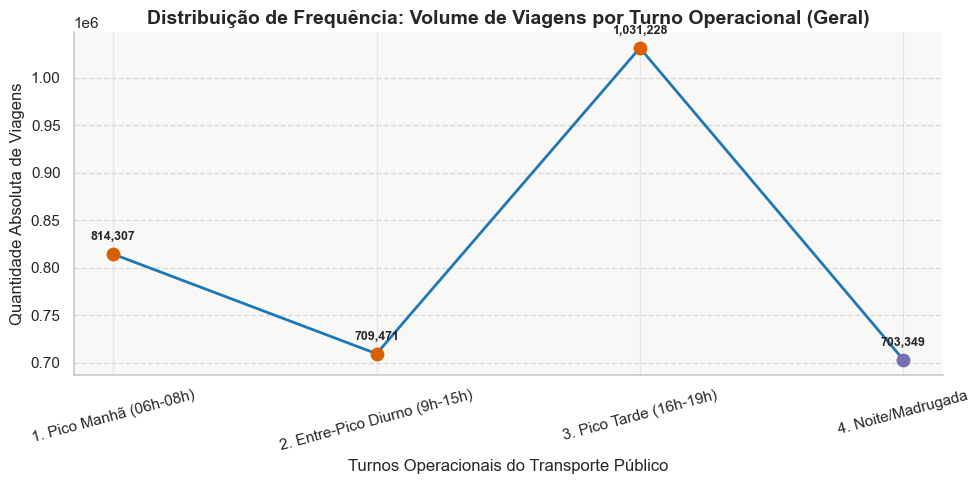

=== ESTATÍSTICAS DESCRITIVAS - VOLUME POR TURNO (GERAL) ===
                           Turno  Total_Viagens  Pct_do_Total  Subsidio_Total
0        1. Pico Manhã (06h-08h)         814307         24.99      1924746.50
1  2. Entre-Pico Diurno (9h-15h)         709471         21.77      1655003.80
2        3. Pico Tarde (16h-19h)        1031228         31.65      2779837.15
3             4. Noite/Madrugada         703349         21.59      2105243.40

Média de viagens por turno: 814,589
Desvio padrão entre turnos: 153,141
Turno de maior movimento: 3. Pico Tarde (16h-19h) (1,031,228 viagens | 31.65% do total)
Turno de menor movimento: 4. Noite/Madrugada (703,349 viagens | 21.59% do total)


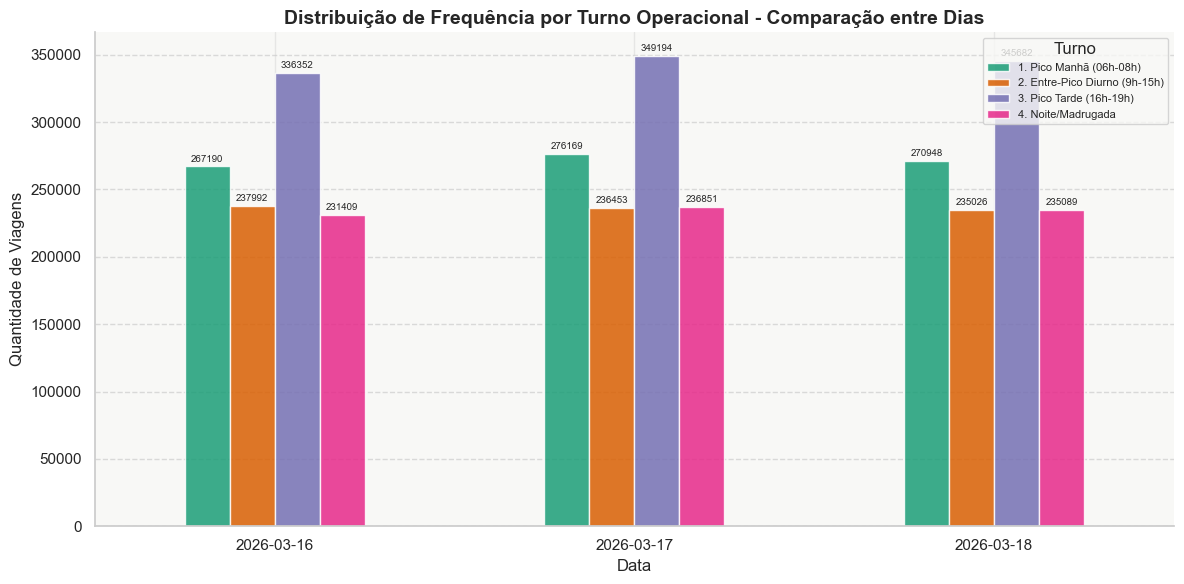


=== ESTATÍSTICAS DESCRITIVAS - VOLUME POR TURNO E DIA ===
Turno       1. Pico Manhã (06h-08h)  2. Entre-Pico Diurno (9h-15h)  \
data                                                                 
2026-03-16                   267190                         237992   
2026-03-17                   276169                         236453   
2026-03-18                   270948                         235026   

Turno       3. Pico Tarde (16h-19h)  4. Noite/Madrugada  
data                                                     
2026-03-16                   336352              231409  
2026-03-17                   349194              236851  
2026-03-18                   345682              235089  

=== PERCENTUAL DE CADA TURNO DENTRO DE CADA DIA ===
Turno       1. Pico Manhã (06h-08h)  2. Entre-Pico Diurno (9h-15h)  \
data                                                                 
2026-03-16                    24.90                          22.18   
2026-03-17                    25.14  

In [22]:
# 1. Passo:  função para categorizar as horas em momentos do dia
def mapear_turno(hora_bruta):
    if 6 <= hora_bruta <= 8:
        return '1. Pico Manhã (06h-08h)'
    elif 16 <= hora_bruta <= 19:
        return '3. Pico Tarde (16h-19h)'
    elif 9 <= hora_bruta <= 15:
        return '2. Entre-Pico Diurno (9h-15h)'
    else:
        return '4. Noite/Madrugada'

# 2. Passo: Aplicar a função no DataFrame criando a nova coluna 'Turno'
Bu['Turno'] = Bu['hora'].apply(mapear_turno)

# 3. Passo: Calcular o volume de viagens e o subsídio por turno (agregado - mantido para visão geral)
resumo_turnos = Bu.groupby('Turno').agg(
    Total_Viagens=('Data_da_Transacao', 'count'),
    Subsidio_Total=('Vl_Subsidio', 'sum')
).reset_index()

# 4. Passo: Plotar gráfico de linha mostrando a progressão por turno
plt.figure(figsize=(10, 5))
plt.plot(resumo_turnos['Turno'], resumo_turnos['Total_Viagens'],
         marker='o', linewidth=2, color='#1f77b4')

# Destaca os pontos de pico com cor diferente e anota o valor de cada turno
for i, row in resumo_turnos.iterrows():
    cor_ponto = '#d95f02' if 'Pico' in row['Turno'] else '#7570b3'
    plt.scatter(row['Turno'], row['Total_Viagens'], color=cor_ponto, s=80, zorder=3)
    plt.annotate(f"{row['Total_Viagens']:,.0f}",
                  (row['Turno'], row['Total_Viagens']),
                  textcoords="offset points", xytext=(0, 10),
                  ha='center', fontsize=9, fontweight='bold')

plt.title('Distribuição de Frequência: Volume de Viagens por Turno Operacional (Geral)', fontsize=14, fontweight='bold')
plt.xlabel('Turnos Operacionais do Transporte Público')
plt.ylabel('Quantidade Absoluta de Viagens')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('imgs/frequencia_sindicato_linha.png', bbox_inches='tight', dpi=150)
plt.show()
plt.close()

# === Estatísticas descritivas do gráfico geral por turno ===
total_viagens_geral = resumo_turnos['Total_Viagens'].sum()
resumo_turnos['Pct_do_Total'] = (resumo_turnos['Total_Viagens'] / total_viagens_geral * 100).round(2)
turno_pico = resumo_turnos.loc[resumo_turnos['Total_Viagens'].idxmax()]
turno_minimo = resumo_turnos.loc[resumo_turnos['Total_Viagens'].idxmin()]

print("=== ESTATÍSTICAS DESCRITIVAS - VOLUME POR TURNO (GERAL) ===")
print(resumo_turnos[['Turno', 'Total_Viagens', 'Pct_do_Total', 'Subsidio_Total']])
print(f"\nMédia de viagens por turno: {resumo_turnos['Total_Viagens'].mean():,.0f}")
print(f"Desvio padrão entre turnos: {resumo_turnos['Total_Viagens'].std():,.0f}")
print(f"Turno de maior movimento: {turno_pico['Turno']} ({turno_pico['Total_Viagens']:,.0f} viagens | {turno_pico['Pct_do_Total']:.2f}% do total)")
print(f"Turno de menor movimento: {turno_minimo['Turno']} ({turno_minimo['Total_Viagens']:,.0f} viagens | {turno_minimo['Pct_do_Total']:.2f}% do total)")


# === NOVO: Distribuição de frequência por turno, comparando os dias ===
resumo_turnos_dia = Bu.groupby(['data', 'Turno']).size().unstack(fill_value=0)

ax = resumo_turnos_dia.plot(
    kind='bar',
    figsize=(12, 6),
    color=['#1b9e77', '#d95f02', '#7570b3', '#e7298a'],
    alpha=0.85
)

# Anota o valor de cada barra
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', fontsize=7, padding=2)

plt.title('Distribuição de Frequência por Turno Operacional - Comparação entre Dias', fontsize=14, fontweight='bold')
plt.xlabel('Data')
plt.ylabel('Quantidade de Viagens')
plt.xticks(rotation=0)
plt.legend(title='Turno', fontsize=8)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('imgs/frequencia_turnos_por_dia.png', bbox_inches='tight', dpi=150)
plt.show()
plt.close()

# === Estatísticas descritivas do gráfico por dia e turno ===
print("\n=== ESTATÍSTICAS DESCRITIVAS - VOLUME POR TURNO E DIA ===")
print(resumo_turnos_dia)

print("\n=== PERCENTUAL DE CADA TURNO DENTRO DE CADA DIA ===")
print(resumo_turnos_dia.div(resumo_turnos_dia.sum(axis=1), axis=0).mul(100).round(2))

print("\n=== MÉDIA E DESVIO POR TURNO (ENTRE OS DIAS) ===")
estatisticas_turno = resumo_turnos_dia.agg(['mean', 'std']).round(1)
print(estatisticas_turno)

# Turno mais consistente (menor variação relativa) vs mais variável
cv_turno = (estatisticas_turno.loc['std'] / estatisticas_turno.loc['mean'] * 100).round(2)
print("\n=== COEFICIENTE DE VARIAÇÃO (%) POR TURNO ===")
print(cv_turno)
print(f"\nTurno mais consistente entre os dias: {cv_turno.idxmin()} (CV = {cv_turno.min():.2f}%)")
print(f"Turno mais variável entre os dias: {cv_turno.idxmax()} (CV = {cv_turno.max():.2f}%)")

### 7.2 Distribuição de Frequência por Faixas de 2 Horas (Comparação entre Dias)


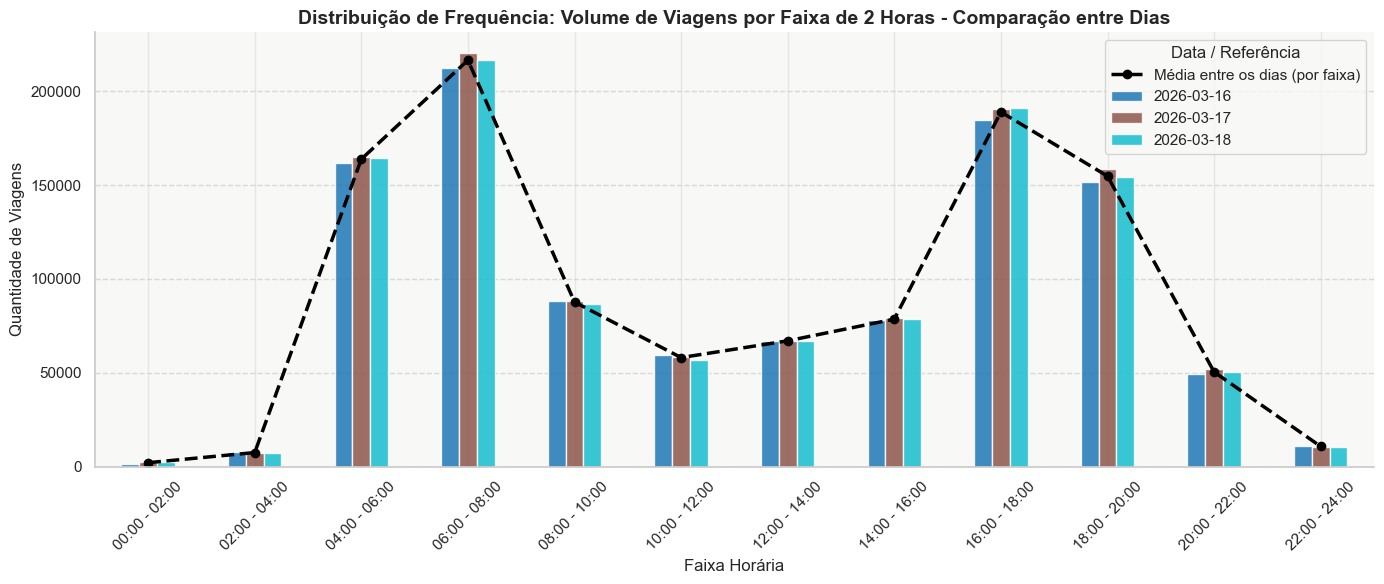

=== VOLUME DE VIAGENS POR FAIXA DE 2H E POR DIA ===
data           2026-03-16  2026-03-17  2026-03-18
Faixa_2h                                         
00:00 - 02:00        1617        2202        2320
02:00 - 04:00        7702        7328        7330
04:00 - 06:00      161996      164897      164625
06:00 - 08:00      212510      220406      216858
08:00 - 10:00       88455       88098       86518
10:00 - 12:00       59360       58164       56673
12:00 - 14:00       66967       66997       67075
14:00 - 16:00       77890       78957       78850
16:00 - 18:00      184926      190708      191257
18:00 - 20:00      151426      158486      154425
20:00 - 22:00       49224       51862       50142
22:00 - 24:00       10870       10562       10672

=== MÉDIA ENTRE OS DIAS, POR FAIXA HORÁRIA ===
Faixa_2h
00:00 - 02:00     2046.30
02:00 - 04:00     7453.30
04:00 - 06:00   163839.30
06:00 - 08:00   216591.30
08:00 - 10:00    87690.30
10:00 - 12:00    58065.70
12:00 - 14:00    67013.00
14:00 - 1

In [23]:
# === DIVISÃO DE FREQUÊNCIA: Faixas de 2 em 2 horas, comparando os dias (20/21/22) + linha de média ===

# 1. Passo: Criar a coluna de faixa horária (intervalos de 2 em 2 horas)
def mapear_faixa_2h(hora_bruta):
    inicio = (hora_bruta // 2) * 2
    fim = inicio + 2
    return f"{inicio:02d}:00 - {fim:02d}:00"

Bu['Faixa_2h'] = Bu['hora'].apply(mapear_faixa_2h)

# 2. Passo: Garantir a ordem correta das faixas no eixo X
ordem_faixas = [f"{h:02d}:00 - {h+2:02d}:00" for h in range(0, 24, 2)]
Bu['Faixa_2h'] = pd.Categorical(Bu['Faixa_2h'], categories=ordem_faixas, ordered=True)

# 3. Passo: Calcular a contagem de viagens por faixa horária e por dia
resumo_faixas_dia = Bu.groupby(['Faixa_2h', 'data']).size().unstack(fill_value=0)

# 4. Passo: Calcular a média entre os dias, para cada faixa horária
media_por_faixa = resumo_faixas_dia.mean(axis=1)

# 5. Passo: Plotar gráfico de barras agrupadas (uma cor por dia, lado a lado)
ax = resumo_faixas_dia.plot(
    kind='bar',
    figsize=(14, 6),
    colormap='tab10',
    alpha=0.85
)

# 6. Passo: Adicionar a linha de média (entre os dias) de cada faixa horária
plt.plot(range(len(media_por_faixa)), media_por_faixa.values,
         color='black', linewidth=2.5, linestyle='--', marker='o',
         label='Média entre os dias (por faixa)')

plt.title('Distribuição de Frequência: Volume de Viagens por Faixa de 2 Horas - Comparação entre Dias', 
          fontsize=14, fontweight='bold')
plt.xlabel('Faixa Horária')
plt.ylabel('Quantidade de Viagens')
plt.xticks(rotation=45)
plt.legend(title='Data / Referência')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('imgs/frequencia_faixa_2h_por_dia.png', bbox_inches='tight', dpi=150)
plt.show()
plt.close()

# 7. Passo: Exibir a tabela com os valores
print("=== VOLUME DE VIAGENS POR FAIXA DE 2H E POR DIA ===")
print(resumo_faixas_dia)
print("\n=== MÉDIA ENTRE OS DIAS, POR FAIXA HORÁRIA ===")
print(media_por_faixa.round(1))

# === ANÁLISE DESCRITIVA: Média diária de passageiros (viagens) ===
viagens_por_dia = Bu.groupby('data').size()
media_diaria_viagens = viagens_por_dia.mean()

print("\n=== TOTAL DE VIAGENS POR DIA ===")
print(viagens_por_dia)

print(f"\n=== MÉDIA DIÁRIA DE PASSAGEIROS (VIAGENS) ===")
print(f"Média diária: {media_diaria_viagens:,.0f} viagens/dia")
print(f"Desvio-padrão entre os dias: {viagens_por_dia.std():,.0f}")
print(f"Dia com maior volume: {viagens_por_dia.idxmax()} ({viagens_por_dia.max():,} viagens)")
print(f"Dia com menor volume: {viagens_por_dia.idxmin()} ({viagens_por_dia.min():,} viagens)")

### 7.3  Distribuido por perfil pagante

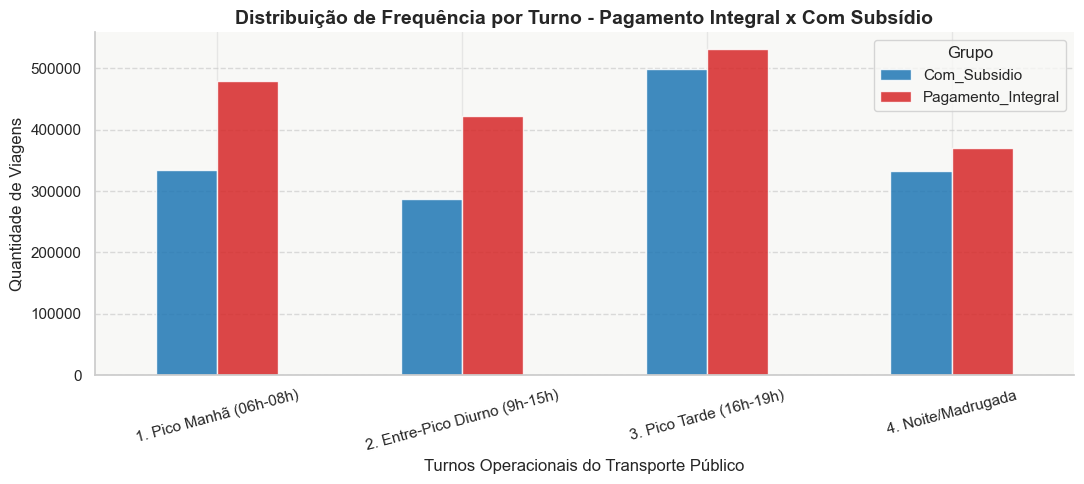

=== TABELA DE FREQUÊNCIA POR TURNO E GRUPO ===
Grupo_Pagamento                Com_Subsidio  Pagamento_Integral
Turno                                                          
1. Pico Manhã (06h-08h)              334728              479579
2. Entre-Pico Diurno (9h-15h)        286930              422541
3. Pico Tarde (16h-19h)              499327              531901
4. Noite/Madrugada                   333305              370044

=== PERCENTUAL DENTRO DE CADA TURNO ===
Grupo_Pagamento                Com_Subsidio  Pagamento_Integral
Turno                                                          
1. Pico Manhã (06h-08h)               41.11               58.89
2. Entre-Pico Diurno (9h-15h)         40.44               59.56
3. Pico Tarde (16h-19h)               48.42               51.58
4. Noite/Madrugada                    47.39               52.61


In [28]:
# === DIVISÃO DE FREQUÊNCIA: Volume por Turno, separado por Grupo de Pagamento ===
resumo_turno_grupo = Bu.groupby(['Turno', 'Grupo_Pagamento']).size().unstack(fill_value=0)

plt.figure(figsize=(11, 5))
resumo_turno_grupo.plot(kind='bar', ax=plt.gca(), color=['#1f77b4', '#d62728'], alpha=0.85)

plt.title('Distribuição de Frequência por Turno - Pagamento Integral x Com Subsídio', fontsize=14, fontweight='bold')
plt.xlabel('Turnos Operacionais do Transporte Público')
plt.ylabel('Quantidade de Viagens')
plt.xticks(rotation=15)
plt.legend(title='Grupo')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('imgs/frequencia_grupo_pagamento.png', bbox_inches='tight', dpi=150)
plt.show()
plt.close()

print("=== TABELA DE FREQUÊNCIA POR TURNO E GRUPO ===")
print(resumo_turno_grupo)
print("\n=== PERCENTUAL DENTRO DE CADA TURNO ===")
print(resumo_turno_grupo.div(resumo_turno_grupo.sum(axis=1), axis=0).mul(100).round(2))

## **8. IDENTIFICAÇÃO DE OUTLIERS**

### 8.1 Outliers via Intervalo Interquartil (IQR) por Turno


=== LIMIAR DE OUTLIER (BASEADO EM IQR) ===
Q1 = R$ 5.00 | Q3 = R$ 9.25 | IQR = R$ 4.25
Limite superior (Q3 + 1.5*IQR) = R$ 15.62

Total de outliers (Vl_Trans > R$ 15.62): 134,063 (4.11% da base)

=== OUTLIERS POR TURNO ===
                               Quantidade  Media  Maximo
Turno                                                   
1. Pico Manhã (06h-08h)             35002  21.59   74.40
2. Entre-Pico Diurno (9h-15h)       23055  21.42   74.40
3. Pico Tarde (16h-19h)             43429  21.86   57.60
4. Noite/Madrugada                  32577  22.15   74.40

Total de outliers: 134,063
                               Quantidade  Pct_dos_Outliers
Turno                                                      
1. Pico Manhã (06h-08h)             35002             26.11
2. Entre-Pico Diurno (9h-15h)       23055             17.20
3. Pico Tarde (16h-19h)             43429             32.39
4. Noite/Madrugada                  32577             24.30

=== TAXA DE INCIDÊNCIA DE OUTLIERS POR TURNO (

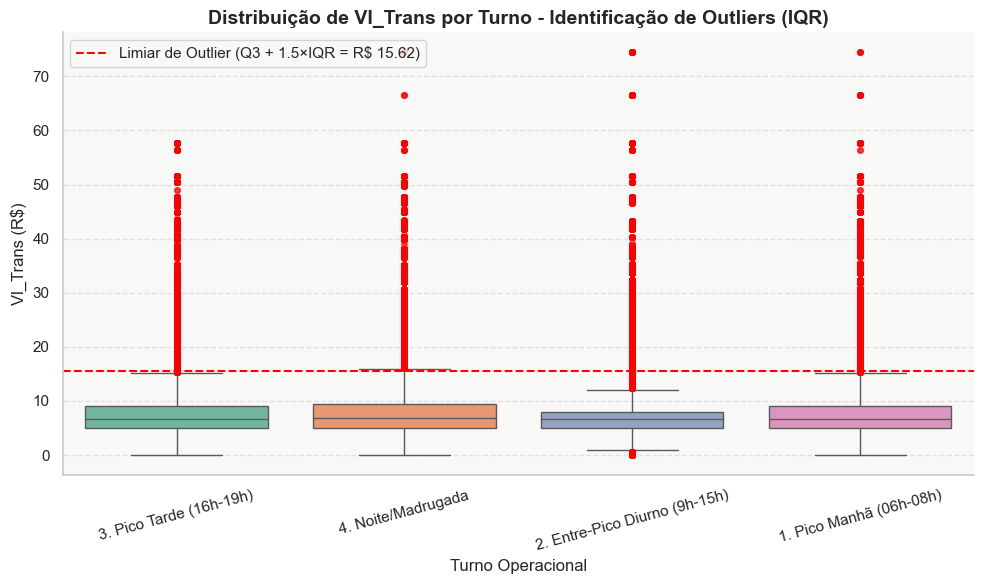

In [24]:
# === OUTLIERS DE TARIFA (Vl_Trans) POR TURNO - LIMIAR BASEADO EM IQR ===

# 1. Passo: Calcular o limiar de outlier via IQR (Q1, Q3, IQR) sobre a base geral
Q1 = Bu['Vl_Trans'].quantile(0.25)
Q3 = Bu['Vl_Trans'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

print("=== LIMIAR DE OUTLIER (BASEADO EM IQR) ===")
print(f"Q1 = R$ {Q1:.2f} | Q3 = R$ {Q3:.2f} | IQR = R$ {IQR:.2f}")
print(f"Limite superior (Q3 + 1.5*IQR) = R$ {limite_superior:.2f}")

# 2. Passo: Filtrar os outliers segundo esse limiar
outliers_iqr = Bu[Bu['Vl_Trans'] > limite_superior]

print(f"\nTotal de outliers (Vl_Trans > R$ {limite_superior:.2f}): {len(outliers_iqr):,} "
      f"({len(outliers_iqr)/len(Bu)*100:.2f}% da base)")

# 3. Passo: Quantidade, média e máximo dos outliers por turno
print("\n=== OUTLIERS POR TURNO ===")
outliers_por_turno = outliers_iqr.groupby('Turno').agg(
    Quantidade=('Vl_Trans', 'count'),
    Media=('Vl_Trans', 'mean'),
    Maximo=('Vl_Trans', 'max')
).round(2)
print(outliers_por_turno)

# Percentual que cada turno representa do total de outliers
total_outliers = outliers_por_turno['Quantidade'].sum()
outliers_por_turno['Pct_dos_Outliers'] = (outliers_por_turno['Quantidade'] / total_outliers * 100).round(2)

print(f"\nTotal de outliers: {total_outliers:,}")
print(outliers_por_turno[['Quantidade', 'Pct_dos_Outliers']])

# 4. Passo: Taxa de incidência - outliers como % do volume total de cada turno
volume_total_por_turno = Bu.groupby('Turno').size()
taxa_incidencia = (outliers_por_turno['Quantidade'] / volume_total_por_turno * 100).round(4)

print("\n=== TAXA DE INCIDÊNCIA DE OUTLIERS POR TURNO (% do volume total do turno) ===")
print(taxa_incidencia)

turno_maior_incidencia = taxa_incidencia.idxmax()
print(f"\nTurno com maior proporção de outliers: {turno_maior_incidencia} "
      f"({taxa_incidencia.max():.4f}% das viagens desse turno)")

# 5. Passo: Gráfico - boxplot de Vl_Trans por turno, com o limiar IQR destacado
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=Bu, x='Turno', y='Vl_Trans',
    hue='Turno', palette='Set2', legend=False,
    fliersize=4,
    flierprops={"markerfacecolor": "red", "markeredgecolor": "red", "alpha": 0.5}
)
plt.axhline(limite_superior, color='red', linestyle='--', linewidth=1.5,
            label=f'Limiar de Outlier (Q3 + 1.5×IQR = R$ {limite_superior:.2f})')
plt.title('Distribuição de Vl_Trans por Turno - Identificação de Outliers (IQR)', fontsize=14, fontweight='bold')
plt.xlabel('Turno Operacional')
plt.ylabel('Vl_Trans (R$)')
plt.xticks(rotation=15)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('imgs/outliers_por_turno_iqr.png', bbox_inches='tight', dpi=150)
plt.show()
plt.close()

### 8.2 Comparação entre Perfis (Integral x Subsidiado) por Dia


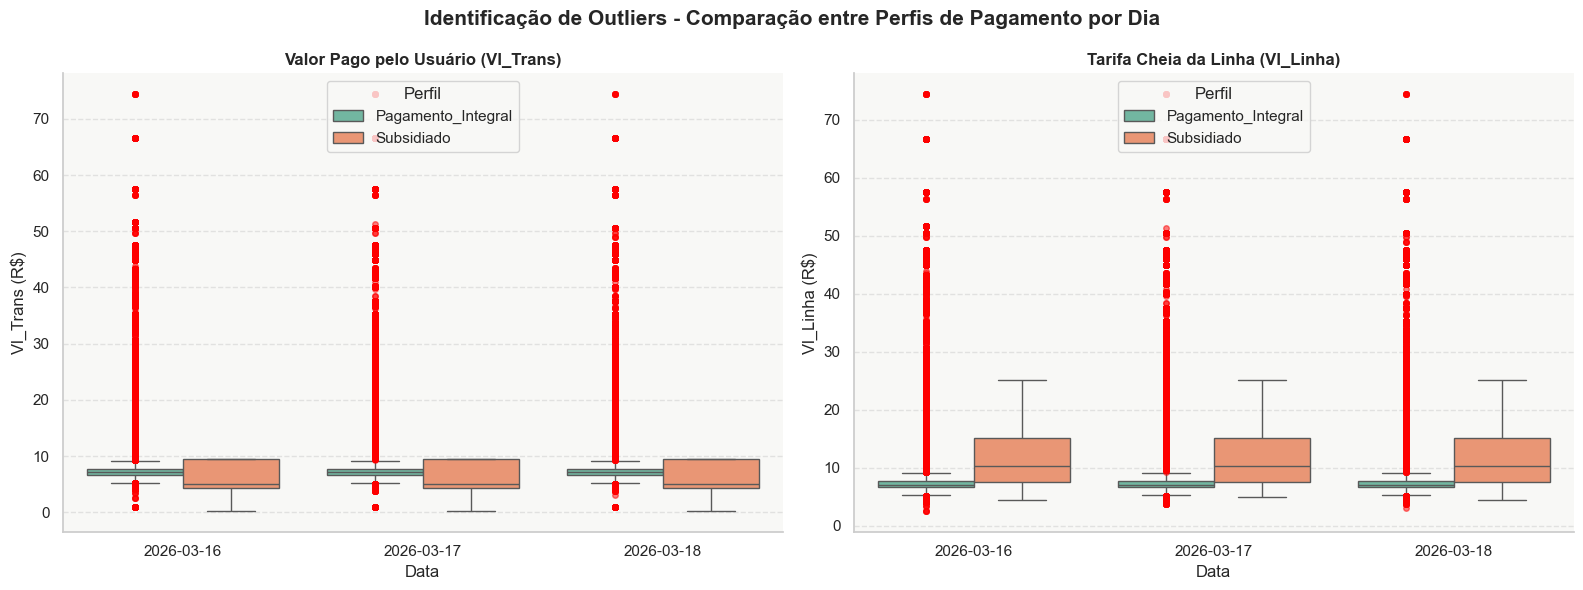

In [25]:
# === NOVO: Identificação de Outliers - Comparação entre Perfis (Integral x Subsidiado) por Dia ===
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Identificação de Outliers - Comparação entre Perfis de Pagamento por Dia', fontsize=15, fontweight='bold')

# Filtra apenas os perfis de interesse para a comparação
perfis_interesse = ['Pagamento_Integral', 'Subsidiado']
Bu_comparacao = Bu[Bu['Perfil'].isin(perfis_interesse)].copy()

# 1. Painel - Vl_Trans (Valor Pago pelo Usuário)
sns.boxplot(
    data=Bu_comparacao,
    x='data',
    y='Vl_Trans',
    hue='Perfil',
    palette='Set2',
    fliersize=4,
    flierprops={"markerfacecolor": "red", "markeredgecolor": "red", "alpha": 0.5},
    ax=axes[0]
)
axes[0].set_title('Valor Pago pelo Usuário (Vl_Trans)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Data')
axes[0].set_ylabel('Vl_Trans (R$)')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)
axes[0].legend(title='Perfil')

# 2. Painel - Vl_Linha (Tarifa Cheia)
sns.boxplot(
    data=Bu_comparacao,
    x='data',
    y='Vl_Linha',
    hue='Perfil',
    palette='Set2',
    fliersize=4,
    flierprops={"markerfacecolor": "red", "markeredgecolor": "red", "alpha": 0.5},
    ax=axes[1]
)
axes[1].set_title('Tarifa Cheia da Linha (Vl_Linha)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Data')
axes[1].set_ylabel('Vl_Linha (R$)')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)
axes[1].legend(title='Perfil')

plt.tight_layout()
plt.savefig('imgs/outliers_perfil_dia.png', bbox_inches='tight', dpi=150)
plt.show()
plt.close()

### 8.3 Análise de Impacto Social: Transporte de Massa x Segmentado

Classificação dos modais em **Transporte de Massa** (SUPERVIA, METRÔ RIO, BARCAS) e **Transporte Segmentado** (TRANSONIBUS, SETRERJ, SETRANSDUC, VANS INTERMUNICIPAIS, SINTERJ, RIO ÔNIBUS, SETRANSOL, NÃO FILIADOS), com indicadores de volume, tarifas e eficiência do subsídio.


=== DISTRIBUIÇÃO POR TIPO DE MODAL ===
Tipo_Modal
Transporte Segmentado    2498257
Transporte de Massa       760098
Name: count, dtype: int64


=== INDICADOR 1: ESTATÍSTICAS TARIFÁRIAS E DE SUBSÍDIO ===
                      Vl_Linha                   Vl_Trans                    \
                          mean median  std   max     mean median  std   max   
Tipo_Modal                                                                    
Transporte Segmentado    10.72   7.70 5.18 74.40     7.88   7.10 4.65 74.40   
Transporte de Massa       7.56   7.60 0.34  7.90     5.74   5.00 1.64  7.90   

                      Vl_Subsidio                    
                             mean median  std   max  
Tipo_Modal                                           
Transporte Segmentado        2.83   0.00 4.39 25.15  
Transporte de Massa          1.82   2.60 1.63  7.60  


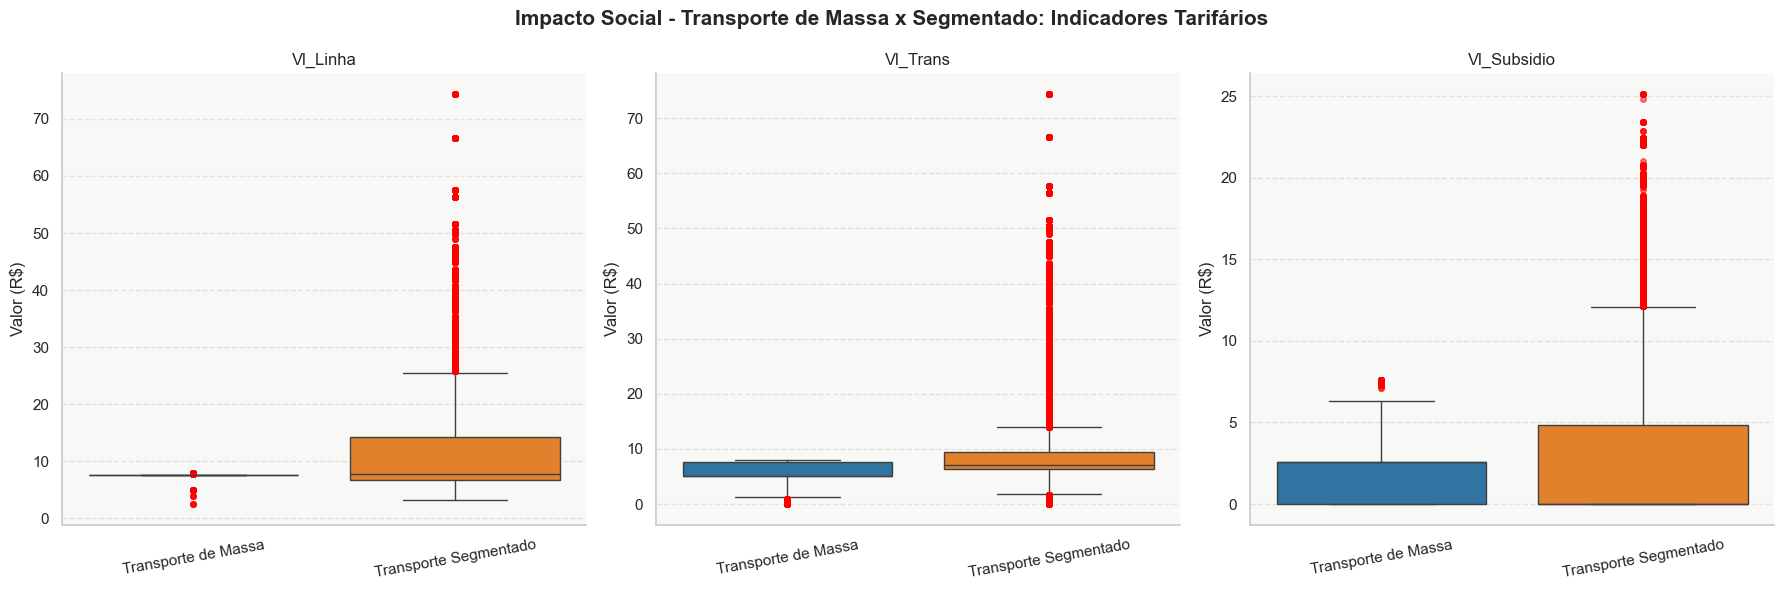



=== INDICADOR 2: VOLUME DE VIAGENS POR TIPO DE MODAL ===
                       Total_Viagens  Cartoes_Unicos  Pct_Viagens
Tipo_Modal                                                       
Transporte Segmentado        2498257          730902        76.67
Transporte de Massa           760098          251968        23.33


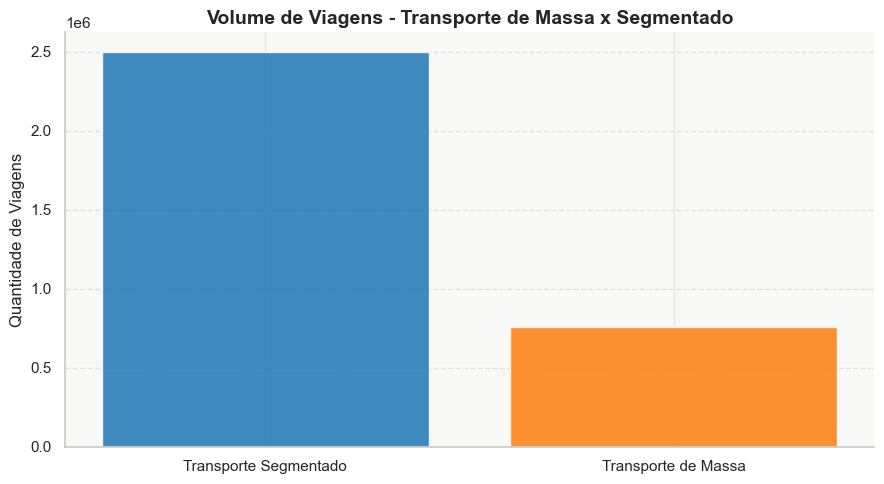



=== INDICADOR 3: EFICIÊNCIA DO SUBSÍDIO POR MODAL ===
                       Total_Viagens  Subsidio_Total  \
Tipo_Modal                                             
Transporte Segmentado        2498257      7081566.70   
Transporte de Massa           760098      1383264.15   

                       Subsidio_Medio_Por_Viagem  Pct_Viagens_Subsidiadas  
Tipo_Modal                                                                 
Transporte Segmentado                       2.83                    39.77  
Transporte de Massa                         1.82                    60.42  


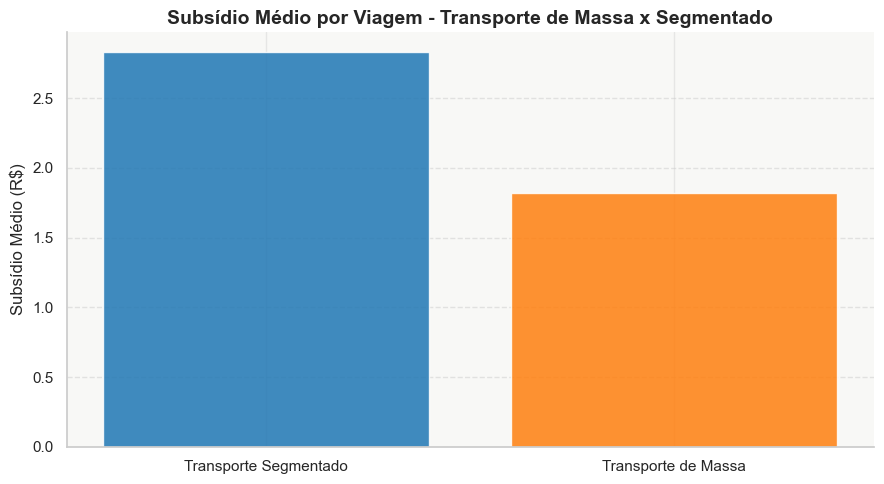



=== SÍNTESE: CUSTO DE SUBSÍDIO POR CADA 1 MILHÃO DE VIAGENS ===
                       Total_Viagens  Subsidio_Total  \
Tipo_Modal                                             
Transporte Segmentado        2498257      7081566.70   
Transporte de Massa           760098      1383264.15   

                       Subsidio_Por_Milhao_Viagens  
Tipo_Modal                                          
Transporte Segmentado                   2834602.97  
Transporte de Massa                     1819849.74  


In [26]:
# === ANÁLISE DE IMPACTO SOCIAL: TRANSPORTE DE MASSA x SEGMENTADO ===

# 1. Passo: Classificação dos modais
modais_massa = ['SUPERVIA', 'METRÔ RIO', 'BARCAS']
modais_segmentado = ['TRANSONIBUS', 'SETRERJ', 'SETRANSDUC', 'VANS INTERMUNICIPAIS',
                      'SINTERJ', 'RIO ÔNIBUS', 'SETRANSOL', 'NÃO FILIADOS']

def classificar_modal(sindicato):
    if sindicato in modais_massa:
        return 'Transporte de Massa'
    elif sindicato in modais_segmentado:
        return 'Transporte Segmentado'
    else:
        return 'Não Classificado'

Bu['Tipo_Modal'] = Bu['Sindicato'].apply(classificar_modal)

print("=== DISTRIBUIÇÃO POR TIPO DE MODAL ===")
print(Bu['Tipo_Modal'].value_counts())


# === INDICADOR 1: TARIFA E SUBSÍDIO (Vl_Trans, Vl_Subsidio, Vl_Linha) ===
print("\n\n=== INDICADOR 1: ESTATÍSTICAS TARIFÁRIAS E DE SUBSÍDIO ===")
resumo_tarifario = Bu.groupby('Tipo_Modal')[['Vl_Linha', 'Vl_Trans', 'Vl_Subsidio']].agg(['mean', 'median', 'std', 'max']).round(2)
print(resumo_tarifario)

# Boxplots comparativos
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Impacto Social - Transporte de Massa x Segmentado: Indicadores Tarifários', fontsize=15, fontweight='bold')

for i, coluna in enumerate(['Vl_Linha', 'Vl_Trans', 'Vl_Subsidio']):
    sns.boxplot(
        data=Bu[Bu['Tipo_Modal'] != 'Não Classificado'],
        x='Tipo_Modal',
        y=coluna,
        hue='Tipo_Modal',
        palette={'Transporte de Massa': '#1f77b4', 'Transporte Segmentado': '#ff7f0e'},
        legend=False,
        fliersize=4,
        flierprops={"markerfacecolor": "red", "markeredgecolor": "red", "alpha": 0.5},
        ax=axes[i]
    )
    axes[i].set_title(coluna)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Valor (R$)')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)
    axes[i].tick_params(axis='x', rotation=10)

plt.tight_layout()
plt.savefig('imgs/impacto_social_tarifario.png', bbox_inches='tight', dpi=150)
plt.show()
plt.close()


# === INDICADOR 2: VOLUME DE VIAGENS (escala do impacto) ===
print("\n\n=== INDICADOR 2: VOLUME DE VIAGENS POR TIPO DE MODAL ===")
volume_modal = Bu.groupby('Tipo_Modal').agg(
    Total_Viagens=('Data_da_Transacao', 'count'),
    Cartoes_Unicos=('Cartao_Hash', 'nunique')
)
volume_modal['Pct_Viagens'] = (volume_modal['Total_Viagens'] / volume_modal['Total_Viagens'].sum() * 100).round(2)
print(volume_modal)

plt.figure(figsize=(9, 5))
volume_plot = volume_modal[volume_modal.index != 'Não Classificado']
plt.bar(volume_plot.index, volume_plot['Total_Viagens'],
        color=['#1f77b4', '#ff7f0e'], alpha=0.85)
plt.title('Volume de Viagens - Transporte de Massa x Segmentado', fontsize=14, fontweight='bold')
plt.ylabel('Quantidade de Viagens')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('imgs/impacto_social_volume.png', bbox_inches='tight', dpi=150)
plt.show()
plt.close()


# === INDICADOR 3: EFICIÊNCIA DO SUBSÍDIO POR PASSAGEIRO/VIAGEM ===
print("\n\n=== INDICADOR 3: EFICIÊNCIA DO SUBSÍDIO POR MODAL ===")

eficiencia_subsidio = Bu.groupby('Tipo_Modal').agg(
    Total_Viagens=('Data_da_Transacao', 'count'),
    Subsidio_Total=('Vl_Subsidio', 'sum'),
    Subsidio_Medio_Por_Viagem=('Vl_Subsidio', 'mean'),
    Pct_Viagens_Subsidiadas=('Vl_Subsidio', lambda x: (x > 0).mean() * 100)
).round(2)

print(eficiencia_subsidio)

# Custo do subsídio por viagem - gráfico comparativo
plt.figure(figsize=(9, 5))
eficiencia_plot = eficiencia_subsidio[eficiencia_subsidio.index != 'Não Classificado']
plt.bar(eficiencia_plot.index, eficiencia_plot['Subsidio_Medio_Por_Viagem'],
        color=['#1f77b4', '#ff7f0e'], alpha=0.85)
plt.title('Subsídio Médio por Viagem - Transporte de Massa x Segmentado', fontsize=14, fontweight='bold')
plt.ylabel('Subsídio Médio (R$)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('imgs/impacto_social_eficiencia_subsidio.png', bbox_inches='tight', dpi=150)
plt.show()
plt.close()


# === SÍNTESE: CUSTO TOTAL DE SUBSÍDIO POR MILHÃO DE VIAGENS ===
print("\n\n=== SÍNTESE: CUSTO DE SUBSÍDIO POR CADA 1 MILHÃO DE VIAGENS ===")
sintese = eficiencia_subsidio[eficiencia_subsidio.index != 'Não Classificado'].copy()
sintese['Subsidio_Por_Milhao_Viagens'] = (sintese['Subsidio_Total'] / sintese['Total_Viagens'] * 1_000_000).round(2)
print(sintese[['Total_Viagens', 'Subsidio_Total', 'Subsidio_Por_Milhao_Viagens']])